# Practice 1: PyTorch FashionMNIST Classification

## MLP vs DiagnosticCNN — Comparison

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Import Libraries | Load PyTorch, src modules, detect device | — |
| 2 | Load Dataset | Download FashionMNIST + apply transforms | `src/data_utils.py` |
| 3 | Explore Dataset | Shape, class distribution, pixel stats | `src/vis_utils.py` |
| 4 | Create DataLoaders | Split into train/test batches | `src/data_utils.py` |
| 5 | Define Models | MLP (Linear) vs DiagnosticCNN (Conv, BN, GAP) | — |
| 6 | Train Both Models | MLP: 30 epochs AdamW + CosineAnnealingLR; CNN: 35 epochs AdamW + CosineAnnealingLR | `src/train_utils.py` |
| 7 | Compare: Loss Curves | Train + test loss curves, solid/dashed for overfitting check | `src/vis_utils.py` |
| 8 | Compare: Confusion Matrices | Per-class TPR/FPR/Precision + heatmaps | `src/eval_utils.py` |
| 9 | Compare: ROC Curves | Per-class ROC curves + AUC scores | `src/eval_utils.py` + `src/vis_utils.py` |
| 10 | Compare: PR Curves | Per-class Precision-Recall curves + AP | `src/eval_utils.py` + `src/vis_utils.py` |
| 11 | Summary Table | Accuracy / ROC-AUC / PR-AUC / Params side-by-side | `src/eval_utils.py` |
| 12 | Save Models | Save .pth weights to `outputs/practice_1/model/` | `src/model_utils.py` |
| 13 | Display Predictions | Predicted vs actual images for MLP + CNN | `src/vis_utils.py` |

---



## 1. Import Libraries

Import `src/` utility modules, PyTorch core, and auto-detect device (MPS > CUDA > CPU).

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data_utils import get_fashionmnist_transforms, load_fashionmnist, get_dataloaders
from src.vis_utils import explore_dataset, plot_losses, plot_confusion_matrix
from src.vis_utils import plot_roc_curves, plot_pr_curves, plot_predictions
from src.model_utils import save_model
from src.train_utils import train_model
from src.eval_utils import evaluate_detailed, get_all_probas_and_labels
from src.eval_utils import compute_roc_auc_scores, compute_pr_auc_scores, print_comparison_table

print(f"PyTorch version: {torch.__version__}")
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")


PyTorch version: 2.13.0+cu130
Using device: cuda


## 2. Load Dataset

Download FashionMNIST (60k train / 10k test) and normalize pixels to [-1, 1] with `ToTensor()` + `Normalize(0.5, 0.5)`.

In [2]:
transform = get_fashionmnist_transforms()
train_dataset, test_dataset = load_fashionmnist(transform)

## 3. Explore Dataset

Print basic info (classes, shape), show 10 sample images, class distribution bar chart, and pixel intensity histogram.

Number of classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Num samples: 60000
Image shape: torch.Size([1, 28, 28])


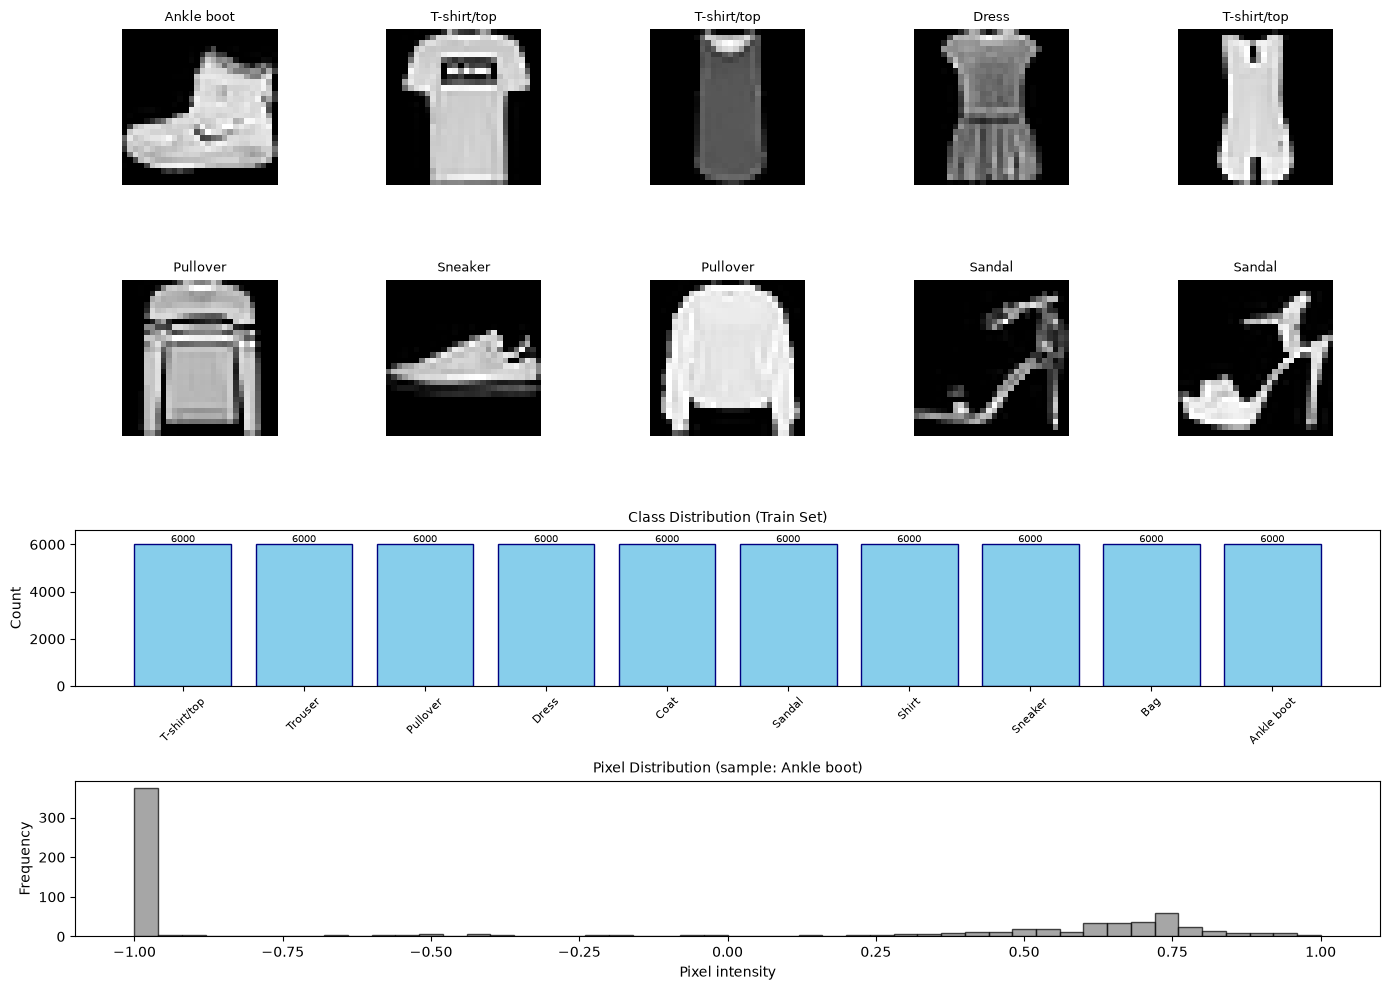

Image tensor shape: torch.Size([1, 28, 28])
Image tensor dtype: torch.float32
Pixel value range: [-1.0000, 1.0000]
Mean pixel value: -0.2372
Std pixel value: 0.7989


In [3]:
class_names = train_dataset.classes
explore_dataset(train_dataset, class_names)

## 4. Create DataLoaders

Batch size = 64. Train loader shuffles, test loader does not.

In [4]:
train_loader, test_loader = get_dataloaders(train_dataset, test_dataset, batch_size=64)
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 938
Test batches: 157


## 4.5. Class Distribution Comparison

Single grouped bar plot comparing train vs test class frequencies to verify the random split maintained class balance.

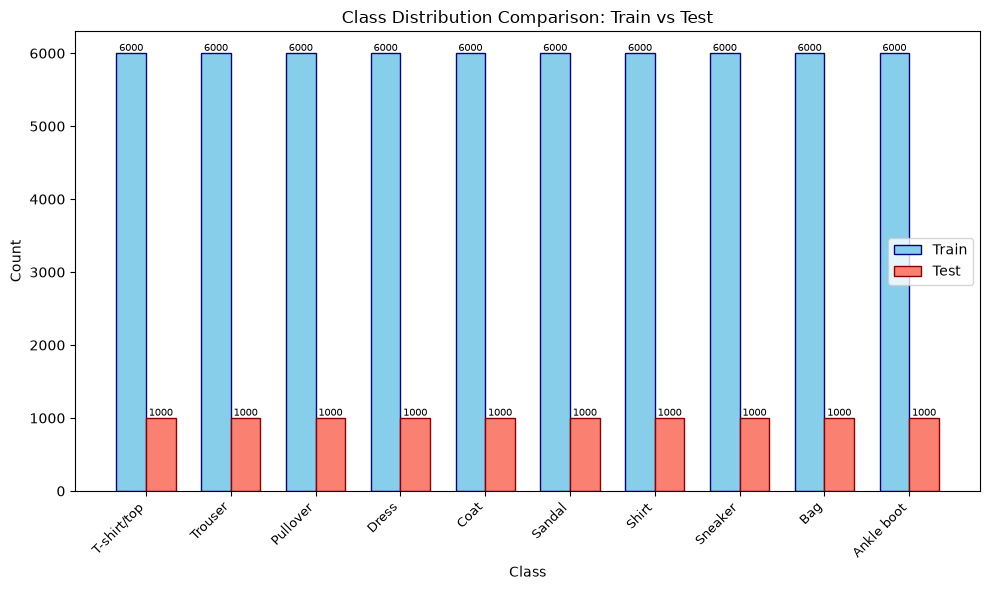


Train set size: 60000  |  Test set size: 10000
Class proportions (Train):  ['10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%']
Class proportions (Test):   ['10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%']


In [5]:
from src.vis_utils import plot_class_distribution_comparison
plot_class_distribution_comparison(train_dataset, test_dataset, class_names)

## 5. Define Models

**MLP:** `784 -> 215 -> 470 -> 10`, GELU, Dropout(0.05).
Best HPs from Optuna (Exp 4, 50 trials, TPE + Median pruner): AdamW, lr=0.002, wd=2e-6, CosineAnnealingLR, 30 epochs.

**DiagnosticCNN:** 3 conv blocks (32→64→128), BatchNorm, ReLU, MaxPool, GAP, Dropout(0.454).
Best HPs from Optuna (Exp 12): AdamW, lr=0.003322, weight_decay=1.39e-5, CosineAnnealingLR, 35 epochs.


In [6]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_1=256, hidden_2=128, num_classes=10, dropout=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, num_classes)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = self.act(self.fc1(x))
        x = self.dropout(x)
        x = self.act(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


class DiagnosticCNN(nn.Module):
    def __init__(self, dropout=0.454):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.net(x)


model_mlp = MLP(hidden_1=215, hidden_2=470, dropout=0.05).to(device)
model_cnn = DiagnosticCNN().to(device)

mlp_params = sum(p.numel() for p in model_mlp.parameters())
cnn_params = sum(p.numel() for p in model_cnn.parameters())
print(f'MLP params: {mlp_params:,}')
print(f'CNN params: {cnn_params:,}')
# DiagnosticCNN has ~134k params — significantly more than the baseline 2-conv CNN (~50k)



MLP params: 235,146
CNN params: 140,778


c:\document\Study documents\Deeplearning_Course\.venv\Lib\site-packages\torch\nn\modules\module.py:1369: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  return t.to(


## 6. Train Both Models

MLP: `CrossEntropyLoss`, `AdamW(lr=0.002, weight_decay=2e-6)`, `CosineAnnealingLR(T_max=30)`, 30 epochs.
Best HPs from Optuna (Exp 4, 50 trials, TPE + Median pruner).

**DiagnosticCNN:** AdamW(lr=0.003322, weight_decay=1.39e-5), CosineAnnealingLR(T_max=35), 35 epochs.
Best HPs from Optuna Bayesian search (Exp 12, 30 trials × 35 epochs, ASHA pruning).



In [7]:
criterion = nn.CrossEntropyLoss()

criterion = nn.CrossEntropyLoss()

print('--- Training MLP ---')
from src.train_utils import train_one_epoch
optimizer_mlp = optim.AdamW(model_mlp.parameters(), lr=0.002, weight_decay=2e-6)
scheduler_mlp = CosineAnnealingLR(optimizer_mlp, T_max=30)
train_losses_mlp = []
test_losses_mlp = []
model_mlp.train()
for epoch in range(30):
    train_loss = train_one_epoch(model_mlp, train_loader, criterion, optimizer_mlp, device)
    train_losses_mlp.append(train_loss)
    scheduler_mlp.step()

    model_mlp.eval()
    tloss = 0.0
    with torch.no_grad():
        for img, lbl in test_loader:
            img, lbl = img.to(device), lbl.to(device)
            tloss += criterion(model_mlp(img), lbl).item()
    test_losses_mlp.append(tloss / len(test_loader))
    model_mlp.train()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/30]  Train: {train_loss:.4f}  Test: {test_losses_mlp[-1]:.4f}')
import os
os.makedirs('../outputs/practice_1/metrics', exist_ok=True)
with open('../outputs/practice_1/metrics/train_losses_MLP.txt', 'w') as f:
    for loss in train_losses_mlp:
        f.write(f'{loss}\n')
with open('../outputs/practice_1/metrics/test_losses_MLP.txt', 'w') as f:
    for loss in test_losses_mlp:
        f.write(f'{loss}\n')

print('\n--- Training DiagnosticCNN ---')
EPOCHS_CNN = 35
optimizer_cnn = optim.AdamW(model_cnn.parameters(), lr=0.003322, weight_decay=1.39e-5)
scheduler_cnn = CosineAnnealingLR(optimizer_cnn, T_max=EPOCHS_CNN)
train_losses_cnn = []
test_losses_cnn = []
model_cnn.train()
for epoch in range(EPOCHS_CNN):
    from src.train_utils import train_one_epoch
    train_loss = train_one_epoch(model_cnn, train_loader, criterion, optimizer_cnn, device)
    train_losses_cnn.append(train_loss)
    scheduler_cnn.step()

    model_cnn.eval()
    tloss = 0.0
    with torch.no_grad():
        for img, lbl in test_loader:
            img, lbl = img.to(device), lbl.to(device)
            tloss += criterion(model_cnn(img), lbl).item()
    test_losses_cnn.append(tloss / len(test_loader))
    model_cnn.train()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS_CNN}]  Train: {train_loss:.4f}  Test: {test_losses_cnn[-1]:.4f}')

import os
os.makedirs('../outputs/practice_1/metrics', exist_ok=True)
with open('../outputs/practice_1/metrics/train_losses_CNN.txt', 'w') as f:
    for loss in train_losses_cnn:
        f.write(f'{loss}\n')
with open('../outputs/practice_1/metrics/test_losses_CNN.txt', 'w') as f:
    for loss in test_losses_cnn:
        f.write(f'{loss}\n')




--- Training MLP ---
Epoch [1/10], Loss: 0.5445
Epoch [2/10], Loss: 0.4097
Epoch [3/10], Loss: 0.3774
Epoch [4/10], Loss: 0.3543
Epoch [5/10], Loss: 0.3371
Epoch [6/10], Loss: 0.3259
Epoch [7/10], Loss: 0.3114
Epoch [8/10], Loss: 0.3004
Epoch [9/10], Loss: 0.2913
Epoch [10/10], Loss: 0.2872

--- Training DiagnosticCNN ---
Epoch [1/35], Loss: 0.4835
Epoch [5/35], Loss: 0.2176
Epoch [10/35], Loss: 0.1456
Epoch [15/35], Loss: 0.0907
Epoch [20/35], Loss: 0.0474
Epoch [25/35], Loss: 0.0222
Epoch [30/35], Loss: 0.0105
Epoch [35/35], Loss: 0.0082


## 7. Compare: Loss Curves

Solid lines = training loss, dashed lines = test loss (with marker shapes).
Train/test divergence signals overfitting; both decreasing together signals good generalization.


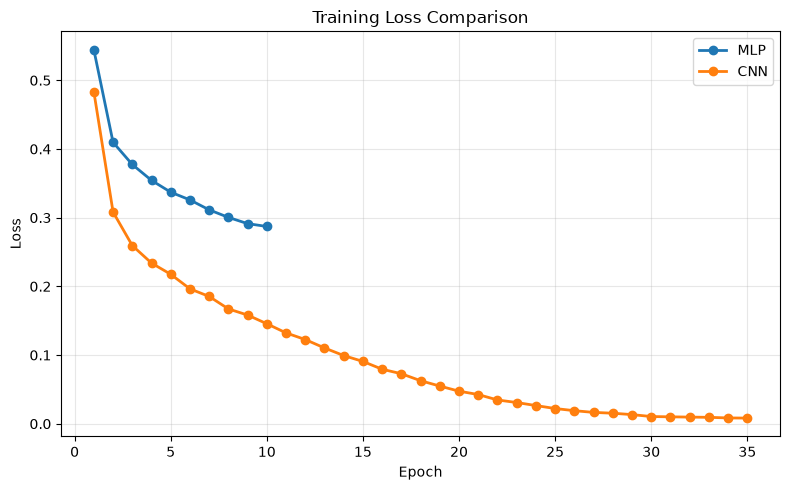

In [8]:
plot_losses({
    'MLP (train)': train_losses_mlp,
    'MLP (test)': test_losses_mlp,
    'CNN (train)': train_losses_cnn,
    'CNN (test)': test_losses_cnn,
}, title='Training and Test Loss Comparison',
   save_path='../outputs/practice_1/plots/train_test_losses.png')


## 8. Compare: Confusion Matrices

Print accuracy, TPR (Recall), FPR, Precision per class + confusion matrix heatmaps for both models.

  Test Accuracy: 87.77%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.7950     0.0149     0.8558
  Trouser             0.9680     0.0024     0.9778
  Pullover            0.7780     0.0199     0.8130
  Dress               0.9130     0.0222     0.8203
  Coat                0.8400     0.0283     0.7671
  Sandal              0.9520     0.0044     0.9597
  Shirt               0.6620     0.0287     0.7196
  Sneaker             0.9550     0.0084     0.9263
  Bag                 0.9620     0.0028     0.9747
  Ankle boot          0.9520     0.0038     0.9655


  Test Accuracy: 93.22%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8920     0.0143     0.8737
  Trouser             0.9840     0.0006     0.9949
  Pullover            0.9000     0.0097     0.9119
  Dress               0.9300     0.0082     0.9263
  Coat                0.9160     0.0

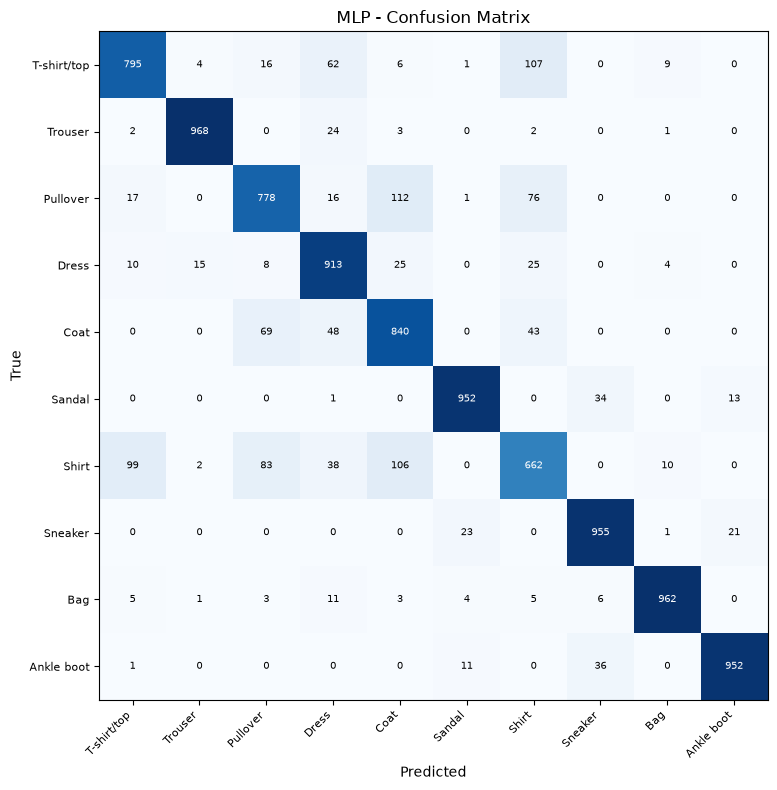

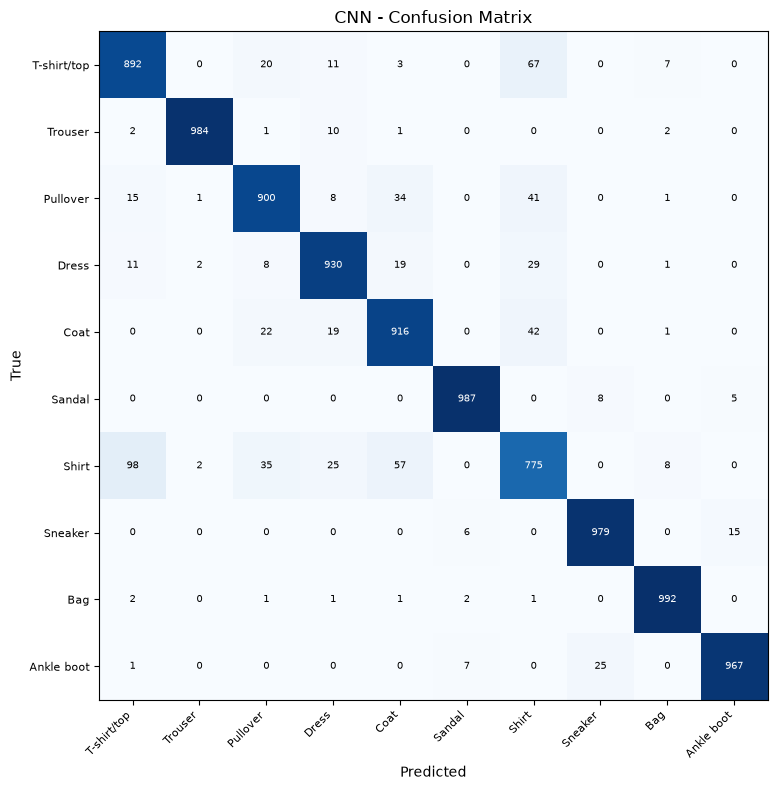

In [9]:
acc_mlp, cm_mlp, _ = evaluate_detailed(model_mlp, test_loader, device, class_names, model_name='MLP')
print('\n')
acc_cnn, cm_cnn, _ = evaluate_detailed(model_cnn, test_loader, device, class_names, model_name='CNN')

plot_confusion_matrix(cm_mlp, class_names, title='MLP - Confusion Matrix',
                      save_path='../outputs/practice_1/plots/confusion_matrix_mlp.png')
plot_confusion_matrix(cm_cnn, class_names, title='CNN - Confusion Matrix',
                      save_path='../outputs/practice_1/plots/confusion_matrix_cnn.png')

## 9. Compare: ROC Curves

Per-class ROC curves (10 subplots), each showing MLP vs CNN with AUC values. Macro AUC printed to console.

MLP macro ROC-AUC: 0.9906
CNN macro ROC-AUC: 0.9961


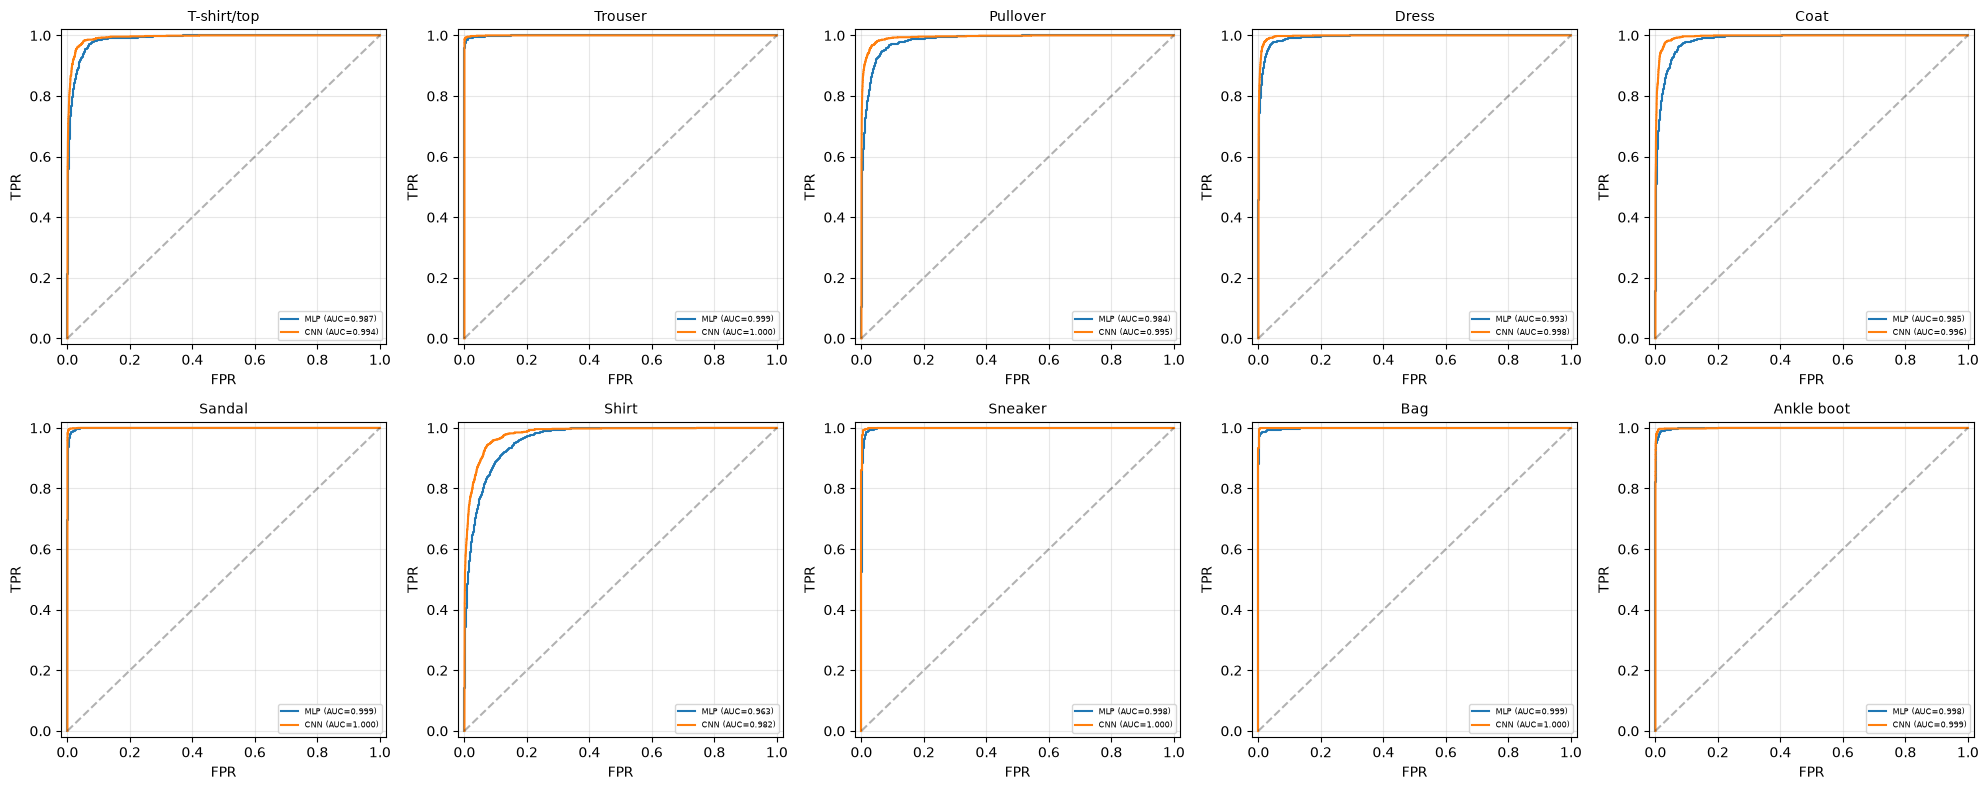

In [10]:
probas_mlp, labels = get_all_probas_and_labels(model_mlp, test_loader, device, 10)
probas_cnn, _ = get_all_probas_and_labels(model_cnn, test_loader, device, 10)

roc_mlp = compute_roc_auc_scores(probas_mlp, labels, model_name='MLP')
roc_cnn = compute_roc_auc_scores(probas_cnn, labels, model_name='CNN')

print(f'MLP macro ROC-AUC: {roc_mlp["macro"]:.4f}')
print(f'CNN macro ROC-AUC: {roc_cnn["macro"]:.4f}')

plot_roc_curves({'MLP': probas_mlp, 'CNN': probas_cnn}, labels, class_names)

## 10. Compare: PR Curves

Per-class Precision-Recall curves (10 subplots), MLP vs CNN with AP (Average Precision) values.

MLP macro PR-AUC (AP): 0.9364
CNN macro PR-AUC (AP): 0.9736


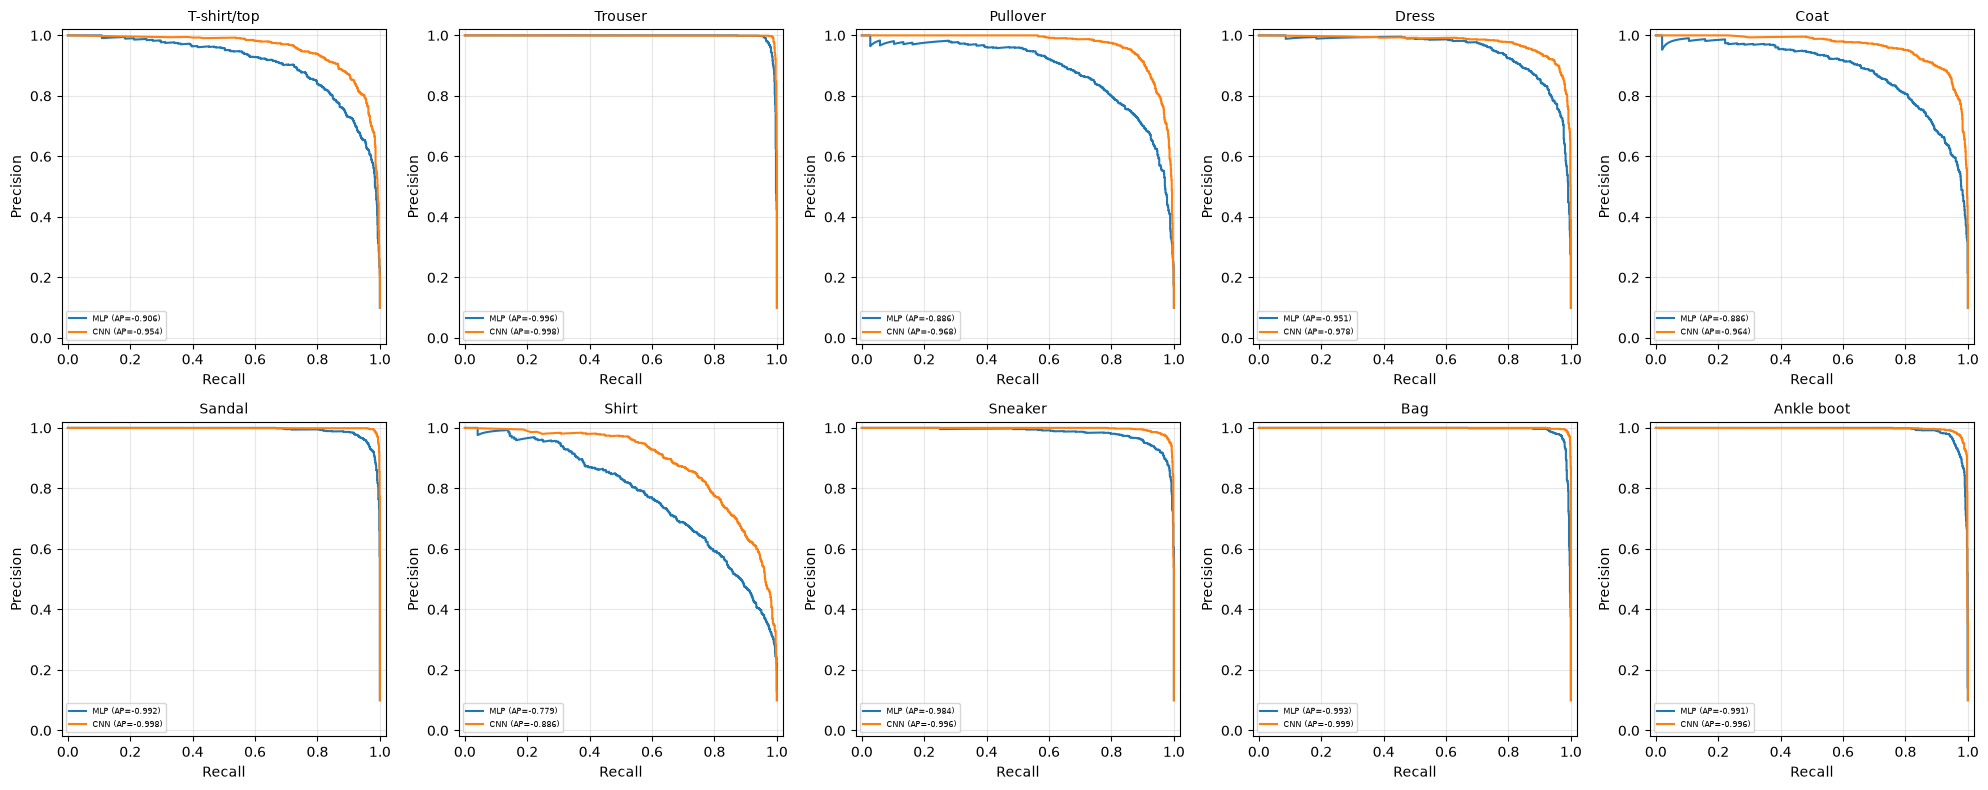

In [11]:
pr_mlp = compute_pr_auc_scores(probas_mlp, labels, model_name='MLP')
pr_cnn = compute_pr_auc_scores(probas_cnn, labels, model_name='CNN')

print(f'MLP macro PR-AUC (AP): {pr_mlp["macro"]:.4f}')
print(f'CNN macro PR-AUC (AP): {pr_cnn["macro"]:.4f}')

plot_pr_curves({'MLP': probas_mlp, 'CNN': probas_cnn}, labels, class_names)

## 11. Summary Table

Compare Accuracy, ROC-AUC, PR-AUC (macro), and parameter count side-by-side, plus per-class breakdown.

In [12]:
print_comparison_table(acc_mlp, acc_cnn, roc_mlp, roc_cnn, pr_mlp, pr_cnn,
                       mlp_params, cnn_params, class_names)

Metric                             MLP          CNN         Diff
---------------------------------------------------------------------------
Test Accuracy (%)               87.77       93.22       +5.45
Macro ROC-AUC                  0.9906      0.9961     +0.0056
Macro PR-AUC (AP)              0.9364      0.9736     +0.0372
Parameters                    235,146     140,778     -94,368

Per-class ROC-AUC                  MLP          CNN
--------------------------------------------------
T-shirt/top                    0.9870      0.9935
Trouser                        0.9992      0.9998
Pullover                       0.9836      0.9945
Dress                          0.9932      0.9975
Coat                           0.9848      0.9956
Sandal                         0.9990      0.9998
Shirt                          0.9634      0.9818
Sneaker                        0.9982      0.9995
Bag                            0.9988      0.9999
Ankle boot                     0.9983      0.9993

Per-cl

## 12. Save Models

Save `.pth` weights to `outputs/model/` for future inference without retraining.

In [13]:
save_model(model_mlp, '../outputs/practice_1/model/mlp_fashion_mnist.pth')
save_model(model_cnn, '../outputs/practice_1/model/cnn_fashion_mnist.pth')

Model saved to ../outputs/practice_1/model/mlp_fashion_mnist.pth
Model saved to ../outputs/practice_1/model/cnn_fashion_mnist.pth


## 13. Display Predicted vs Actual Images

First batch of test set: green = correct, red = wrong. MLP and CNN side-by-side.

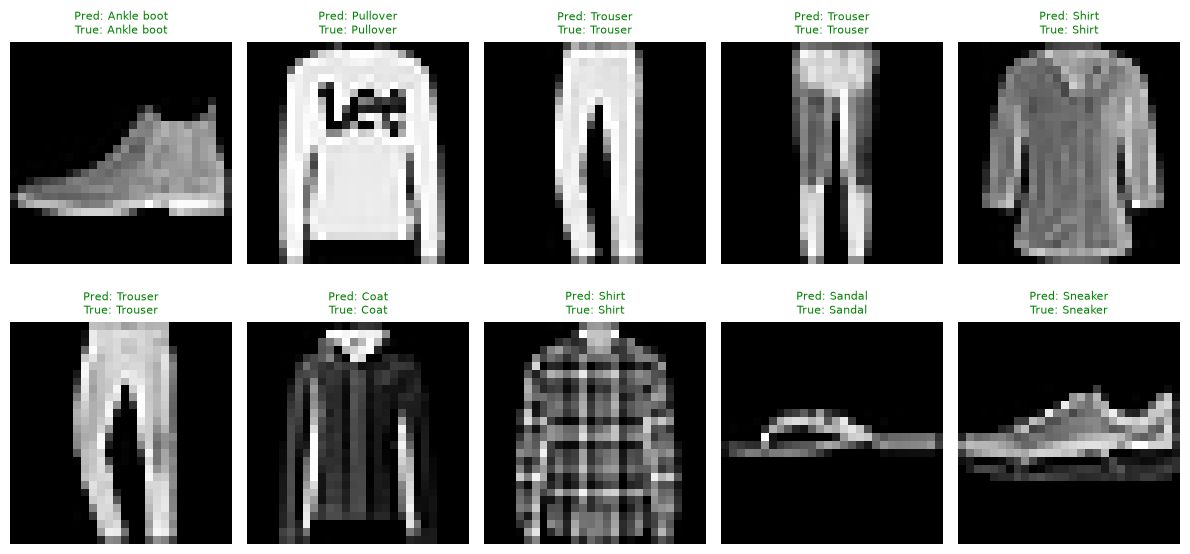

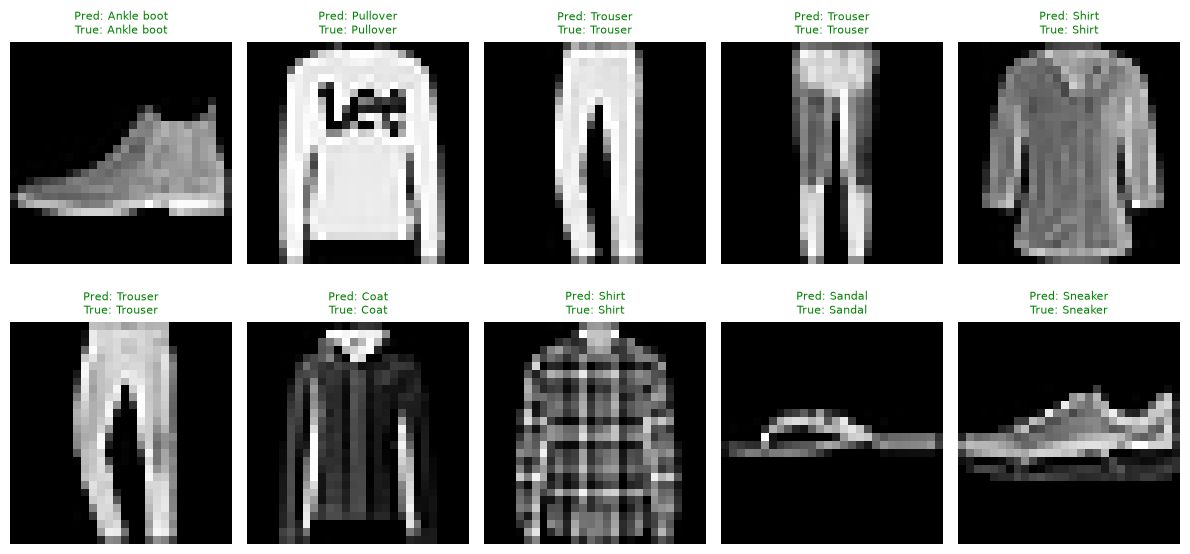

In [14]:
plot_predictions(model_mlp, test_loader, class_names, device,
               '../outputs/practice_1/plots/predictions_mlp.png')
plot_predictions(model_cnn, test_loader, class_names, device,
               '../outputs/practice_1/plots/predictions_cnn.png')